In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

file                  hassan_swing.csv
rows                               952
duration_s                      31.383
mag_axis_for_force               mz_uT
use_abs_field                     True
b0_force_field_uT           728.357118
R0_MM                             25.0
FORCE_SLOPE                      658.7
FORCE_INTERCEPT                 -173.5
max_r_diff_mm                 1.246885
max_force_n                 647.823434
mean_force_n                 87.293749
Name: data10 force params/summary, dtype: object

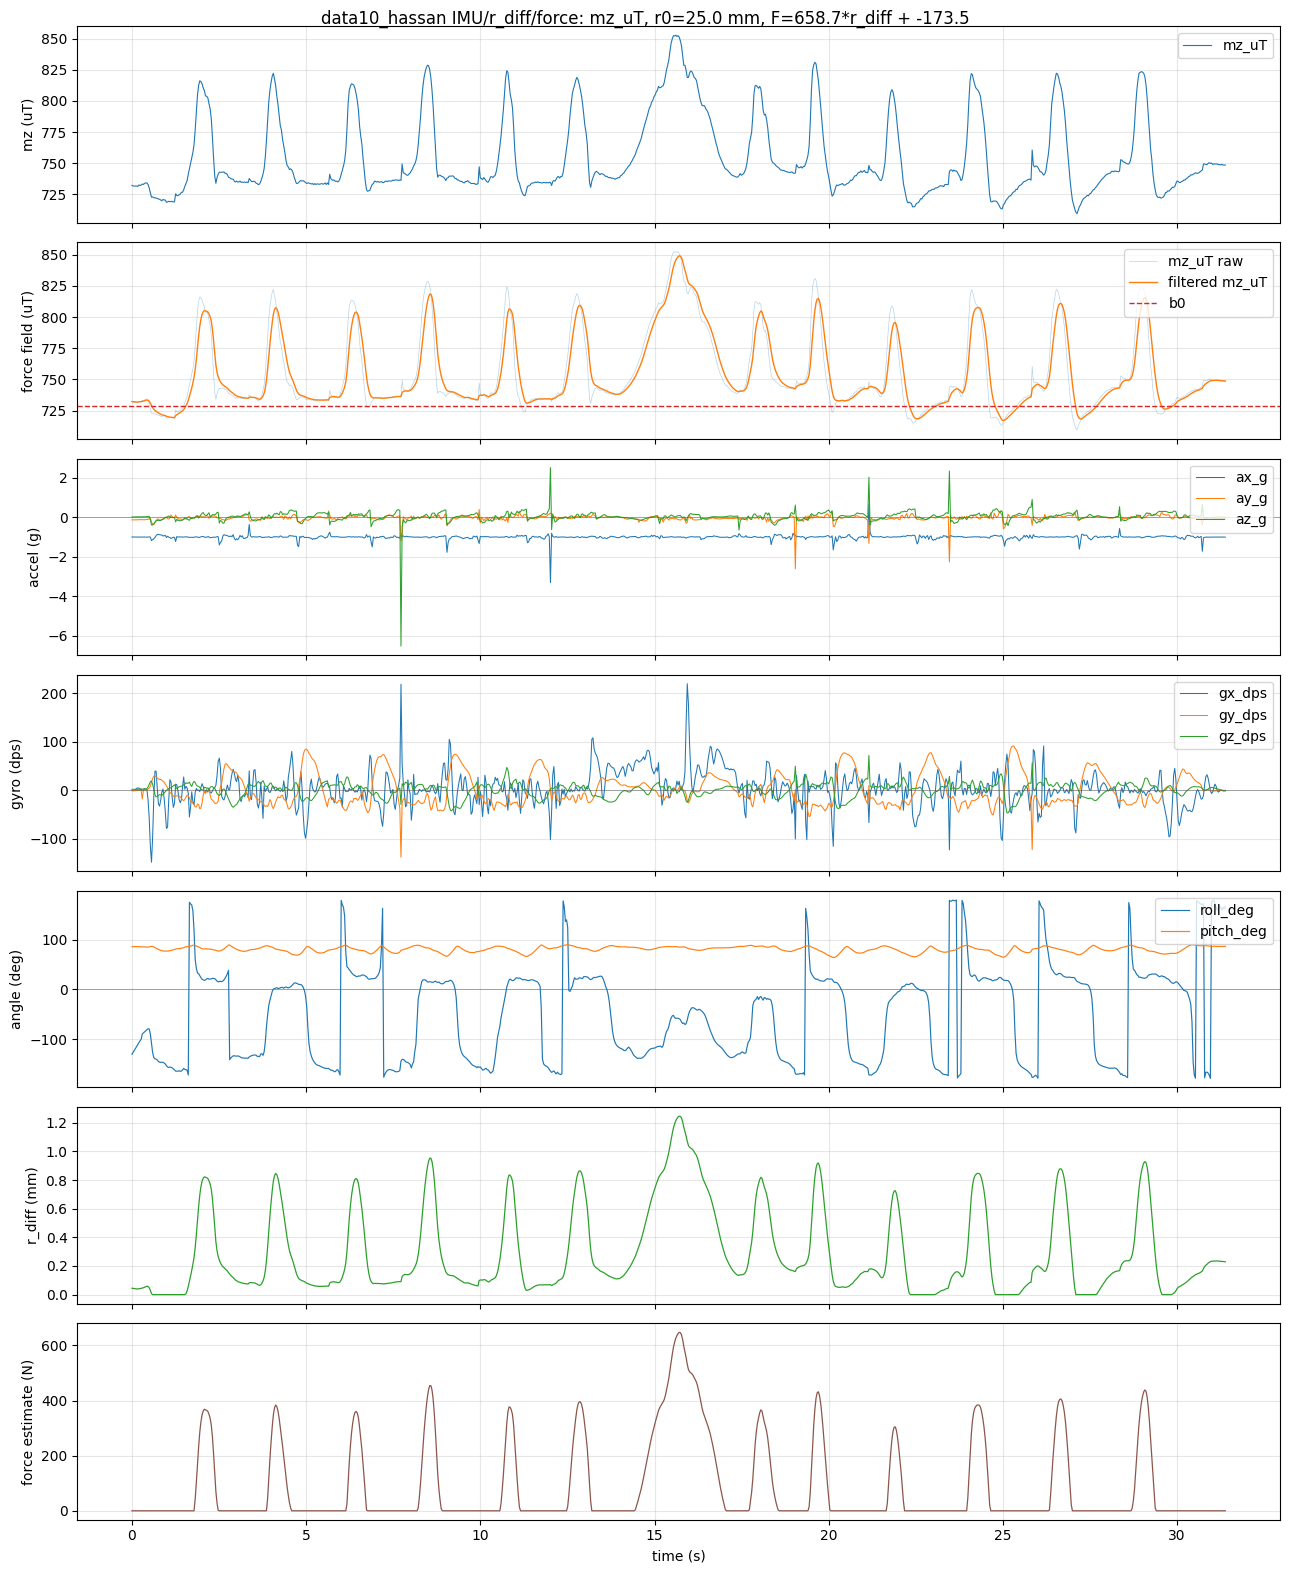

In [5]:
twopt_path = Path("hassan_2pt_left_crutch_right_damaged.csv")
threept_path = Path("hassan3pt_left_crutch_left_damaged.csv")
fourpt_path = Path("hassandata1_4pt_left_crutch_right_damaged.csv")
swing_path = Path("hassan_swing.csv")

CSV_PATH = swing_path
STARTUP_BASELINE_S = 1.0
MAG_LPF_ALPHA = 0.25

# Tune these parameters.
MAG_AXIS = "mz_uT"      # choose: mx_uT, my_uT, mz_uT, or mag_norm_uT
USE_ABS_FIELD = True    # use abs(axis) for single-axis force proxy
R0_MM = 25.0
FORCE_SLOPE = 658.7
FORCE_INTERCEPT = -173.5

RAW_CAPTURE_COLS = [
    "seq", "timestamp_ms",
    "ax_g", "ay_g", "az_g",
    "gx_dps", "gy_dps", "gz_dps",
    "roll_deg", "pitch_deg", "yaw_deg",
    "mx_uT", "my_uT", "mz_uT",
]
MAG_ONLY_COLS = ["seq", "timestamp_ms", "mx_uT", "my_uT", "mz_uT"]


def load_capture_csv(path):
    rows = []
    header = None
    with Path(path).open() as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = [p.strip() for p in line.split(",")]
            if parts[0] == "seq":
                header = parts
                continue
            try:
                rows.append([float(p) for p in parts])
            except ValueError:
                continue

    if not rows:
        return pd.DataFrame()

    width = max(len(r) for r in rows)
    rows = [r + [np.nan] * (width - len(r)) for r in rows]

    if header and len(header) == width:
        cols = header
    elif width >= len(RAW_CAPTURE_COLS):
        cols = RAW_CAPTURE_COLS + [f"extra_{i}" for i in range(width - len(RAW_CAPTURE_COLS))]
    elif width >= len(MAG_ONLY_COLS):
        cols = MAG_ONLY_COLS + [f"extra_{i}" for i in range(width - len(MAG_ONLY_COLS))]
    else:
        cols = [f"col_{i}" for i in range(width)]

    df = pd.DataFrame(rows, columns=cols)
    df["time_s"] = (df["timestamp_ms"] - df["timestamp_ms"].iloc[0]) / 1000.0
    return df


df_force = load_capture_csv(CSV_PATH)
if df_force.empty:
    print(f"No parseable rows in {CSV_PATH}")
elif not {"mx_uT", "my_uT", "mz_uT"}.issubset(df_force.columns):
    print(f"{CSV_PATH} does not include recognized magnetometer columns")
    display(df_force.head())
else:
    df_force["mag_norm_uT"] = np.sqrt(
        df_force["mx_uT"]**2 + df_force["my_uT"]**2 + df_force["mz_uT"]**2
    )

    field = df_force[MAG_AXIS]
    if USE_ABS_FIELD:
        field = field.abs()
    df_force["force_field_uT"] = field
    df_force["force_field_lpf_uT"] = field.ewm(alpha=MAG_LPF_ALPHA, adjust=False).mean()

    startup = df_force[df_force["time_s"] <= STARTUP_BASELINE_S]
    b0 = startup["force_field_lpf_uT"].mean()

    ratio = b0 / df_force["force_field_lpf_uT"]
    ratio = ratio.where((ratio > 0) & np.isfinite(ratio), np.nan)
    df_force["r_mm"] = R0_MM * np.cbrt(ratio)
    df_force["r_diff_mm"] = (R0_MM - df_force["r_mm"]).clip(lower=0.0)
    df_force["force_n"] = (FORCE_SLOPE * df_force["r_diff_mm"] + FORCE_INTERCEPT).clip(lower=0.0)

    display(pd.Series({
        "file": str(CSV_PATH),
        "rows": len(df_force),
        "duration_s": df_force["time_s"].iloc[-1],
        "mag_axis_for_force": MAG_AXIS,
        "use_abs_field": USE_ABS_FIELD,
        "b0_force_field_uT": b0,
        "R0_MM": R0_MM,
        "FORCE_SLOPE": FORCE_SLOPE,
        "FORCE_INTERCEPT": FORCE_INTERCEPT,
        "max_r_diff_mm": df_force["r_diff_mm"].max(),
        "max_force_n": df_force["force_n"].max(),
        "mean_force_n": df_force["force_n"].mean(),
    }, name="data10 force params/summary"))

    fig, axs = plt.subplots(7, 1, figsize=(13, 16), sharex=True)

    axs[0].plot(df_force["time_s"], df_force["mz_uT"], lw=0.8, label="mz_uT")
    axs[0].set_ylabel("mz (uT)")
    axs[0].legend(loc="upper right")
    axs[0].grid(True, alpha=0.3)

    axs[1].plot(df_force["time_s"], df_force["force_field_uT"], lw=0.45, alpha=0.35, label=f"{MAG_AXIS} raw")
    axs[1].plot(df_force["time_s"], df_force["force_field_lpf_uT"], lw=1.0, label=f"filtered {MAG_AXIS}")
    axs[1].axhline(b0, color="C3", ls="--", lw=1.0, label="b0")
    axs[1].set_ylabel("force field (uT)")
    axs[1].legend(loc="upper right")
    axs[1].grid(True, alpha=0.3)

    accel_cols = ["ax_g", "ay_g", "az_g"]
    if set(accel_cols).issubset(df_force.columns):
        for col in accel_cols:
            axs[2].plot(df_force["time_s"], df_force[col], lw=0.75, label=col)
        axs[2].axhline(0, color="0.35", lw=0.7, alpha=0.5)
        axs[2].legend(loc="upper right")
    else:
        axs[2].text(0.5, 0.5, "accel columns not available", ha="center", va="center", transform=axs[2].transAxes)
    axs[2].set_ylabel("accel (g)")
    axs[2].grid(True, alpha=0.3)

    gyro_cols = ["gx_dps", "gy_dps", "gz_dps"]
    if set(gyro_cols).issubset(df_force.columns):
        for col in gyro_cols:
            axs[3].plot(df_force["time_s"], df_force[col], lw=0.75, label=col)
        axs[3].axhline(0, color="0.35", lw=0.7, alpha=0.5)
        axs[3].legend(loc="upper right")
    else:
        axs[3].text(0.5, 0.5, "gyro columns not available", ha="center", va="center", transform=axs[3].transAxes)
    axs[3].set_ylabel("gyro (dps)")
    axs[3].grid(True, alpha=0.3)

    angle_cols = ["roll_deg", "pitch_deg"]
    if set(angle_cols).issubset(df_force.columns):
        for col in angle_cols:
            axs[4].plot(df_force["time_s"], df_force[col], lw=0.85, label=col)
        axs[4].axhline(0, color="0.35", lw=0.7, alpha=0.5)
        axs[4].legend(loc="upper right")
    else:
        axs[4].text(0.5, 0.5, "roll/pitch columns not available", ha="center", va="center", transform=axs[4].transAxes)
    axs[4].set_ylabel("angle (deg)")
    axs[4].grid(True, alpha=0.3)

    axs[5].plot(df_force["time_s"], df_force["r_diff_mm"], lw=0.9, color="C2")
    axs[5].set_ylabel("r_diff (mm)")
    axs[5].grid(True, alpha=0.3)

    axs[6].plot(df_force["time_s"], df_force["force_n"], lw=0.9, color="C5")
    axs[6].set_ylabel("force estimate (N)")
    axs[6].set_xlabel("time (s)")
    axs[6].grid(True, alpha=0.3)

    fig.suptitle(
        f"data10_hassan IMU/r_diff/force: {MAG_AXIS}, r0={R0_MM} mm, "
        
        f"F={FORCE_SLOPE}*r_diff + {FORCE_INTERCEPT}"
    )
    plt.tight_layout()
    plt.show()
